<a href="https://colab.research.google.com/github/kny1209/test2/blob/main/%EA%B0%95%EC%9D%98_8%EA%B8%B0_AI%EC%9D%91%EC%9A%A9_07%EC%B0%A8%EC%8B%9C_03_GAN_basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache direc

런타임 재시작

In [1]:
# 필요 라이브러리 설치

!pip install torchviz | tail -n 1

In [2]:
# PyTorch: 딥러닝 프레임워크
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader


# 데이터셋 관련
from torchvision import datasets, transforms


# 시각화 도구
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# 라이브러리 임포트

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display


# 폰트 관련 용도
import matplotlib.font_manager as fm


# 나눔 고딕 폰트의 경로 명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()


# 기본 폰트 설정
plt.rcParams['font.family'] = font_name


# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14


# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)


# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True


# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False


# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

In [4]:
# GPU가 있으면 사용하고, 없으면 CPU 사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 중인 디바이스: {device}")


# 하이퍼파라미터 (학습 설정값)
batch_size = 128        # 한 번에 처리할 이미지 개수
learning_rate = 0.0002  # 학습 속도 (GAN은 보통 작게 설정)
num_epochs = 30         # 전체 데이터를 몇 번 반복할지
latent_dim = 100        # 노이즈 벡터의 크기 (랜덤 입력)


print(f"\n배치 크기: {batch_size}")
print(f"학습률: {learning_rate}")
print(f"에포크 수: {num_epochs}")
print(f"잠재 차원: {latent_dim}")

사용 중인 디바이스: cuda

배치 크기: 128
학습률: 0.0002
에포크 수: 30
잠재 차원: 100


In [5]:
# 데이터 준비
# 이미지 전처리 : 값을 -1 ~ 1 정규화
# GANG에서 일반적으로 -1 ~ 1 사용

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),  # 0-1 변환
    transforms.Normalize((0.5,), (0.5,))    # -1~1 변환
])

# MNIST 다운
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# 데이터로더 생성
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

In [7]:
print(f'총 학습 이미지 수:{len(train_dataset)}장')
print(f'이미지 크기:28*28 pixel')

총 학습 이미지 수:60000장
이미지 크기:28*28 pixel


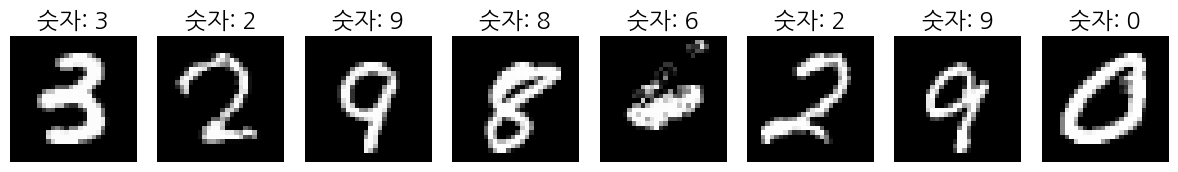

In [8]:
# 샘플 이미지 확인하기
# 실제 데이터가 어떻게 생겼는지 샘플 이미지 가져와 확인

# 첫번째 배치 이미지 가져오기
sample_images, sample_labels =  next(iter(train_loader))

# -1~1 범위 >> 0-1로 복원(시각화용)
sample_images_display = sample_images * 0.5 + 0.5

# 8개 이미지 시각화
plt.figure(figsize=(12, 3))
for i in range(8):
    plt.subplot(1, 8, i+1)
    plt.imshow(sample_images_display[i][0], cmap='gray')
    plt.title(f"숫자: {sample_labels[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [9]:
# 이미지 형태
sample_images[0].shape  # torch.Size([1, 28, 28]) (c,h,w)

# 픽셀 값 범위
print(f'픽셀 값 범위 : {sample_images.min()} ~ {sample_images.max()}')

픽셀 값 범위 : -1.0 ~ 1.0


생성자 만들기 (Generator)

In [10]:
# 생성자 역할 : random noise >> 가짜 이미지(fake image) 생성
# random vector (100차원) >> fake image(28*28)

# 생성자 G 네트워크 구조
# 입력 : 100차원 random vector
# 출력 : 784차원 (28*28)

generator = nn.Sequential(
    # 1번째 층 100 >> 256
    nn.Linear(in_features=latent_dim, out_features=256),
    nn.LeakyReLU(negative_slope=0.2),
    # LeakyReLU : ReLU 보다 안정적(음수를 완전히 0으로 만들지 않기 때문)

    # 2번째 층 256 >> 512
    nn.Linear(256, 512),
    nn.LeakyReLU(0.2),

    # 3번째 층 512 >> 784
    nn.Linear(512, 784),
    nn.Tanh()       # 출력 -1 ~ 1 사이로 만들기 (실제 이미지와 같은 범위)
)

generator = generator.to(device)
print(f'입력 : {latent_dim} 차원 >> 출력 784 차원')

입력 : 100 차원 >> 출력 784 차원


판별자(Discriminator) 만들기

In [11]:
from torch.nn.modules.activation import Sigmoid
# 이미지가 진짜인지 가짜인지 구분
# 이미지(28*28=784 차원) >> 진짜 / 가짜

# Discriminator 네트워크 구조
# 입력 : 784 >> 출력 : 1차원 (진짜일 확률 0-1)

discriminator = nn.Sequential(
    # 1번째 층 784 >> 512
    nn.Linear(784, 512),
    nn.LeakyReLU(negative_slope=0.2),
    nn.Dropout(0.3), # 콤마 추가
    # 드랍아웃 : 과적합 방지(랜덤하게 30% 뉴런 제거)

    # 2번째 층 512 >> 256
    nn.Linear(512, 256),
    nn.LeakyReLU(0.2),
    nn.Dropout(0.3),

    # 3번째 층 256 >> 1
    nn.Linear(256, 1),
    nn.Sigmoid()       # 출력 0-1 사이로 만들기
)

discriminator = discriminator.to(device)

loss 함수와 optimizer 설정하기

In [12]:
# GAN은 두개의 네트워크 따로 학습시킴

# Loss 함수 : Binary Cross Entropy(이진분류)
# 진짜 1 가짜 0 구분하는 문제

criterion = nn.BCELoss()

# optimizer : generator 와 discriminator 각각 따로
optimizer_G = optim.Adam(generator.parameters(), lr=learning_rate, betas=(0.5,0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(0.5,0.999))
# betas : b1, b2
# 일반적으로 betas는 default가 betas=(0.9,0.999) >> Gan에서 betas=(0.5,0.999) 사용
# 모멘텀 b1(0.9) : 방향 (과거의 기울기 정보 얼마나 유지할거니)
# 모멘텀 b2(0.999) : 보폭 (기울기를 제곱한 값을 누적)
# gan은 b1을 0.5 사용 : 생성자(G)와 판별자(D) 서로 경쟁 >> 균형 찾아가는 구조

In [13]:
# 정리
# 학습 전략

# 판별자의 학습 전략
# 진짜 이미지 보여주고 >> 진짜(1) 판별하도록 학습
# 생성자가 만든 가짜 이미지 보여주고 >> 가짜(0) 판별하도록 학습
# Loss_D = Loss(진짜, 1) + Loss(가짜, 0)

# 생성자의 학습 전략
# 새로운 가짜 이미지 생성
# >> 판별자가 진짜(1)?라고 착각하도록 학습 (손실)
# >> Loss_G = Loss(가짜, 1)

# 핵심 : 두 네트워크가 서로 경쟁하면서 점점 똑똑한 네트워크 >> 이미지 잘 생성하기

<Figure size 1200x600 with 0 Axes>

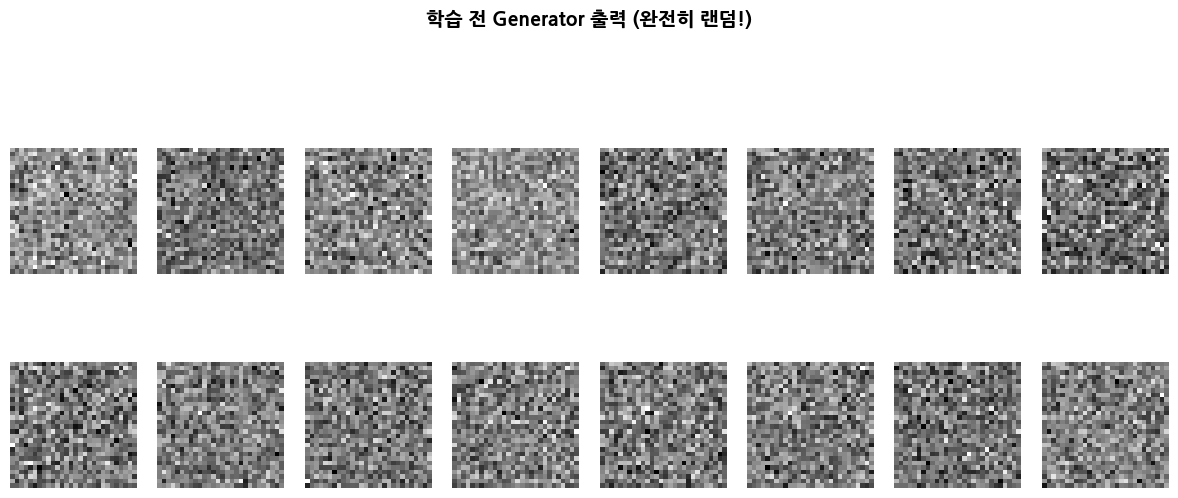

학습 전에는 의미 없는 노이즈만 생성됩니다.


In [14]:
# 학습 전 G 성능 확인
generator.eval()

with torch.no_grad():
    test_noise = torch.randn(16, latent_dim).to(device)

    # 가짜 이미지 생성
    fake_images_before = generator(test_noise)
    fake_images_before = fake_images_before.view(-1, 1, 28, 28).cpu()
    # -1 ~ 1 범위 >> 0-1 변환 (시각화용)
    fake_images_before = fake_images_before * 0.5 + 0.5

plt.figure(figsize=(12, 6))
# betas : b1, b2
# 일반적으로 betas default가 betas=(0.9, 0.999) >> Gan에서 betas=(0.5, 0.999) 사용




# 모멘텀 b1 (beta 1) 0.9 : 방향 (과거의 기울기 (gradient) 정보 얼마나 유지할거니)
# 모멘텀 b2 (beta 2) = 0.999: 보폭 (기울기를 제곱한 값을 누적)
# gan은 b1(beta1)을 0.5 사용 : 생성자(G)와 판변자(D) 서로 경쟁 >> 균형 찾아가는 구조


# 시각화
plt.figure(figsize=(12, 6))
for i in range(16):
    plt.subplot(2, 8, i+1)
    plt.imshow(fake_images_before[i][0], cmap='gray')
    plt.axis('off')
plt.suptitle('학습 전 Generator 출력 (완전히 랜덤!)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


print("학습 전에는 의미 없는 노이즈만 생성됩니다.")


Epoch [1/30] = D_loss : 0.8850, G_loss : 1.3727
Epoch [2/30] = D_loss : 0.7141, G_loss : 2.2138
Epoch [3/30] = D_loss : 0.6335, G_loss : 2.3997
Epoch [4/30] = D_loss : 0.5771, G_loss : 2.6641
Epoch [5/30] = D_loss : 0.5476, G_loss : 2.7265


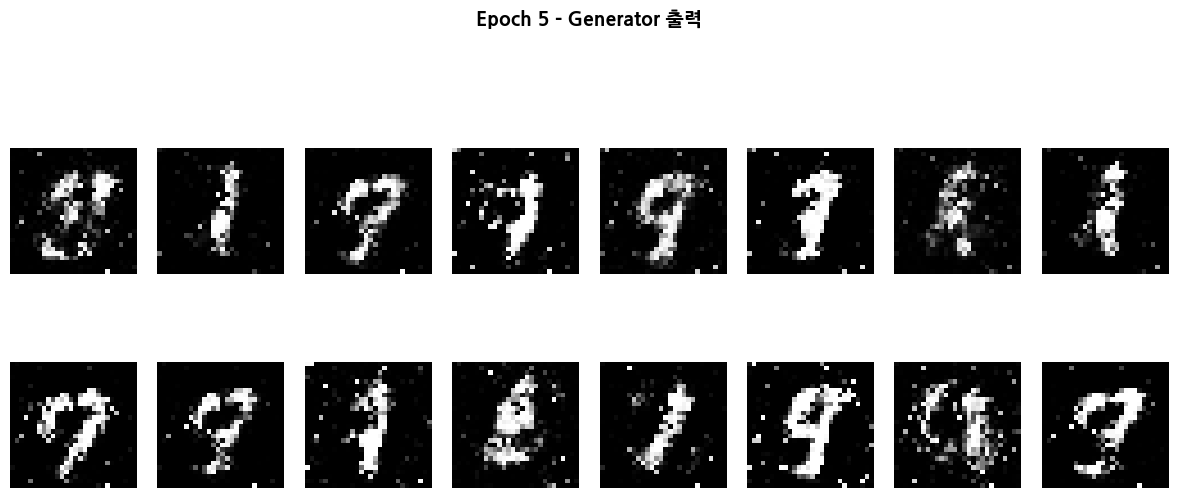

Epoch [6/30] = D_loss : 0.5579, G_loss : 2.6415
Epoch [7/30] = D_loss : 0.5734, G_loss : 2.5378
Epoch [8/30] = D_loss : 0.5977, G_loss : 2.5502
Epoch [9/30] = D_loss : 0.6467, G_loss : 2.4283
Epoch [10/30] = D_loss : 0.6467, G_loss : 2.3568


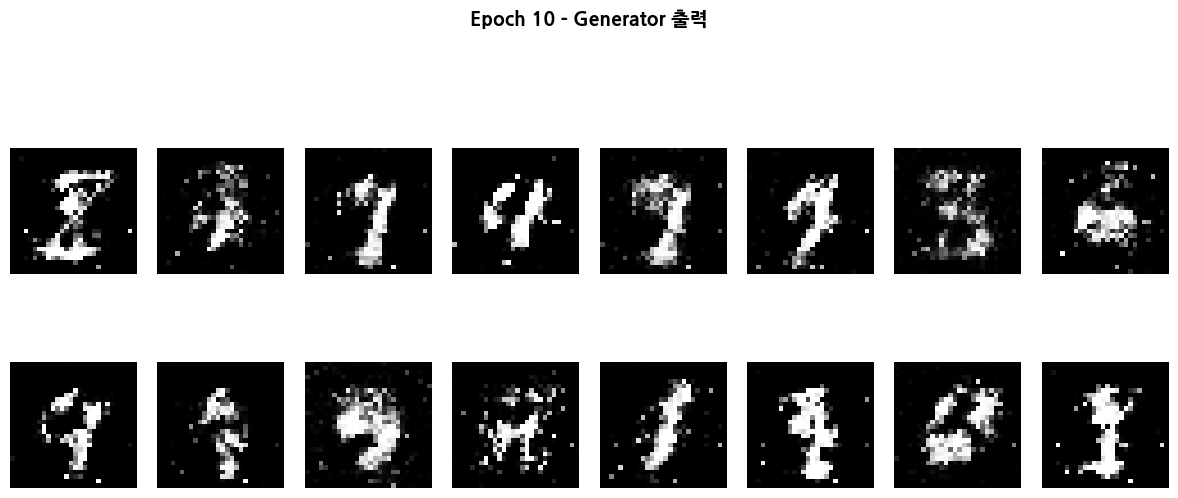

Epoch [11/30] = D_loss : 0.6525, G_loss : 2.2874
Epoch [12/30] = D_loss : 0.6690, G_loss : 2.1701
Epoch [13/30] = D_loss : 0.7465, G_loss : 1.9461
Epoch [14/30] = D_loss : 0.8019, G_loss : 1.7599
Epoch [15/30] = D_loss : 0.8648, G_loss : 1.6041


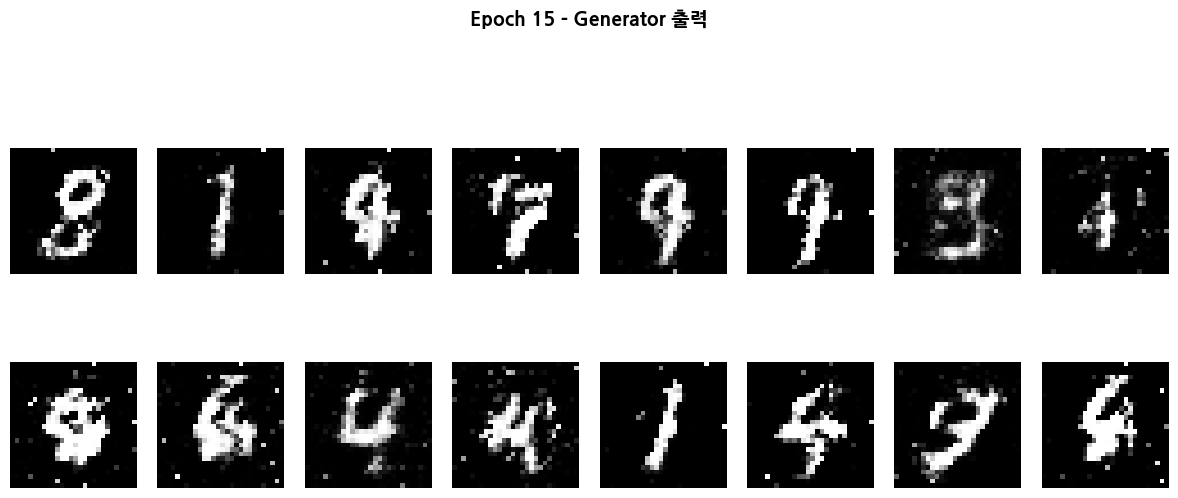

Epoch [16/30] = D_loss : 0.8979, G_loss : 1.5440
Epoch [17/30] = D_loss : 0.9344, G_loss : 1.4500
Epoch [18/30] = D_loss : 0.9611, G_loss : 1.3996
Epoch [19/30] = D_loss : 0.9770, G_loss : 1.3586
Epoch [20/30] = D_loss : 1.0034, G_loss : 1.3163


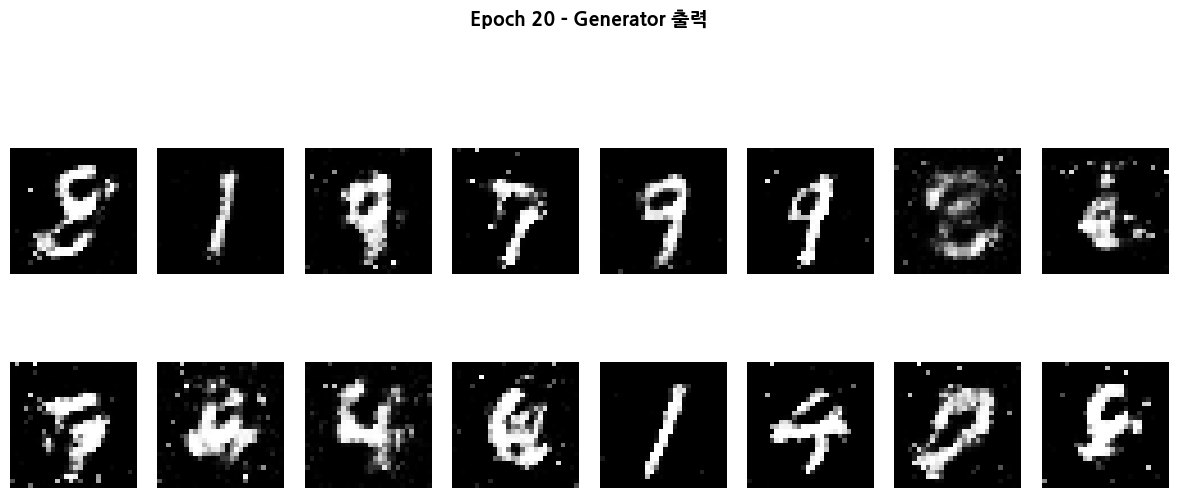

Epoch [21/30] = D_loss : 1.0302, G_loss : 1.2633
Epoch [22/30] = D_loss : 1.0522, G_loss : 1.2302
Epoch [23/30] = D_loss : 1.0588, G_loss : 1.2138
Epoch [24/30] = D_loss : 1.0731, G_loss : 1.1913
Epoch [25/30] = D_loss : 1.0822, G_loss : 1.1804


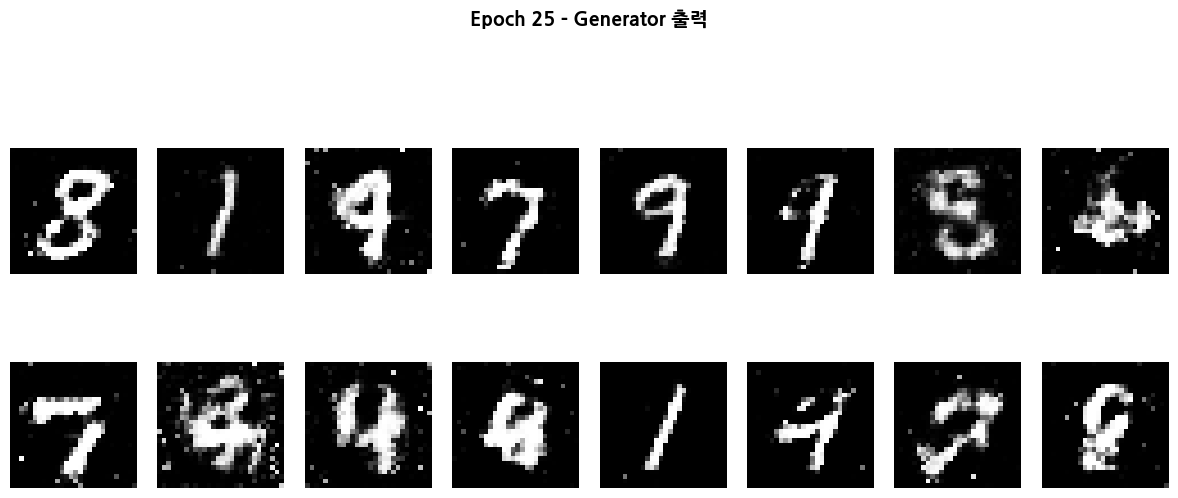

Epoch [26/30] = D_loss : 1.0835, G_loss : 1.1708
Epoch [27/30] = D_loss : 1.0947, G_loss : 1.1637
Epoch [28/30] = D_loss : 1.1056, G_loss : 1.1543
Epoch [29/30] = D_loss : 1.1110, G_loss : 1.1374
Epoch [30/30] = D_loss : 1.1146, G_loss : 1.1341


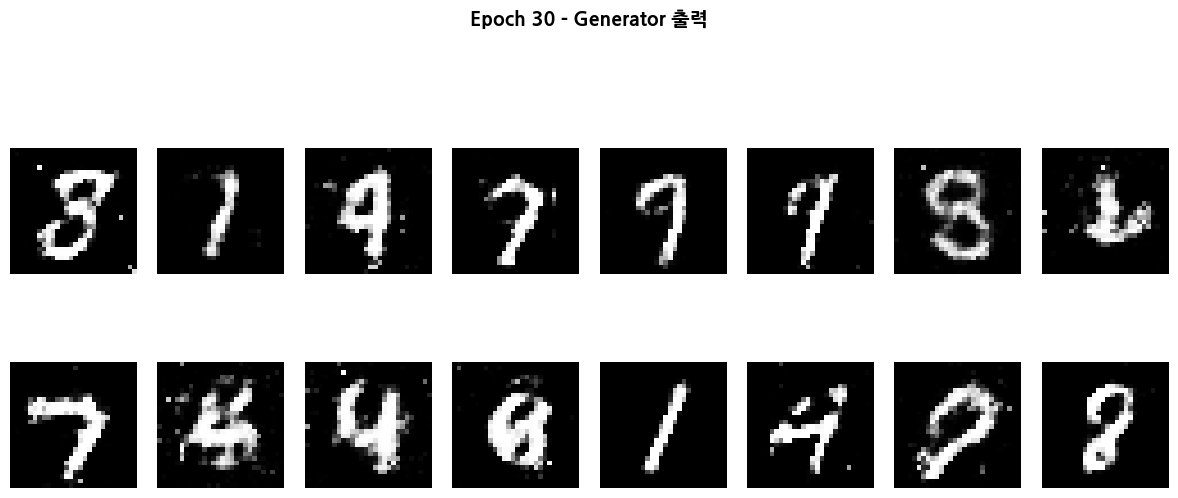

In [15]:
# GAN 학습 시작

# 학습 모드 전환
generator.train()
discriminator.train()

# 손실값 기록
G_losses = []
D_losses = []

# 학습 중간 결과 저장용
fixed_noise = torch.randn(16, latent_dim).to(device) # 고정된 노이즈(비교용)

for epoch in range(num_epochs):
    epoch_G_loss = 0
    epoch_D_loss = 0

    for batch_idx, (real_images, _) in enumerate(train_loader):
        current_batch_size = real_images.size(0)

        # 데이터 gpu/cpu 이동 >> 1차원으로 펼치기(평탄화 작업)
        real_images = real_images.view(current_batch_size, -1).to(device)

        # 레이블 생성 (진짜 1, 가짜 0)
        real_labels = torch.ones(current_batch_size, 1).to(device)
        fake_labels = torch.zeros(current_batch_size, 1).to(device)

        # 판별기 학습
        # 1) 진짜 이미지로 학습
        outputs_real = discriminator(real_images)
        loss_D_real = criterion(outputs_real, real_labels)

        # 2) 가짜 이미지로 학습
        noise = torch.randn(current_batch_size, latent_dim).to(device)
        fake_images = generator(noise)
        outputs_fake = discriminator(fake_images.detach())  # detach 중요
        loss_D_fake = criterion(outputs_fake, fake_labels)

        # 3) 판별기 총손실
        loss_D = loss_D_real + loss_D_fake

        # 4) 판별기 업데이트
        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        # Generator 학습
        noise = torch.randn(current_batch_size, latent_dim).to(device)
        fake_images = generator(noise)

        # 판별자가 가짜를 진짜라고 착각하게 만들기
        outputs = discriminator(fake_images)
        loss_G = criterion(outputs, real_labels)    # 가짜(0)를 진짜(1)로 판별하게 만들기

        # Generator 업데이트
        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

        # 손실값 누적
        epoch_G_loss += loss_G.item()
        epoch_D_loss += loss_D.item()

    # epoch(학습 횟수) 별 평균 손실
    avg_G_loss = epoch_G_loss / len(train_loader)
    avg_D_loss = epoch_D_loss / len(train_loader)
    G_losses.append(avg_G_loss)
    D_losses.append(avg_D_loss)

    print(f'Epoch [{epoch+1}/{num_epochs}] = D_loss : {avg_D_loss:.4f}, G_loss : {avg_G_loss:.4f}')

    # 5 epoch마다 중간 결과 시각화
    if (epoch + 1) % 5 == 0:
        generator.eval()
        with torch.no_grad():
            fake_images_progress = generator(fixed_noise)
            fake_images_progress = fake_images_progress.view(-1, 1, 28, 28).cpu()
            fake_images_progress = fake_images_progress * 0.5 + 0.5

        plt.figure(figsize=(12, 6))
        for i in range(16):
            plt.subplot(2, 8, i+1)
            plt.imshow(fake_images_progress[i][0], cmap='gray')
            plt.axis('off')
        plt.suptitle(f'Epoch {epoch+1} - Generator 출력', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

        generator.train()




학습과정 시각화

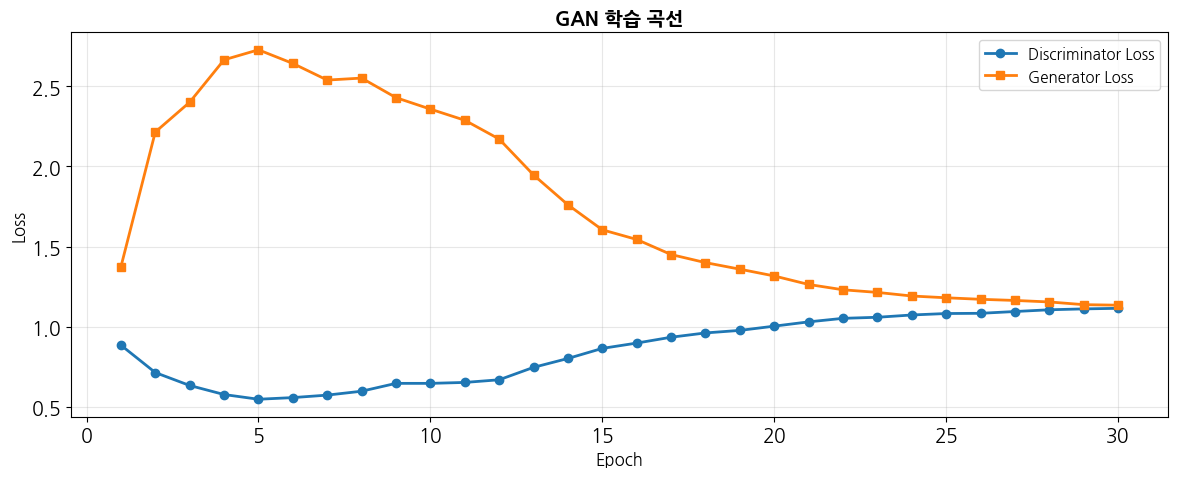

In [16]:
plt.figure(figsize=(12, 5))


plt.plot(range(1, num_epochs+1), D_losses, label='Discriminator Loss', linewidth=2, marker='o')
plt.plot(range(1, num_epochs+1), G_losses, label='Generator Loss', linewidth=2, marker='s')


plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('GAN 학습 곡선', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# 결과 해석

최종 생성 이미지 확인

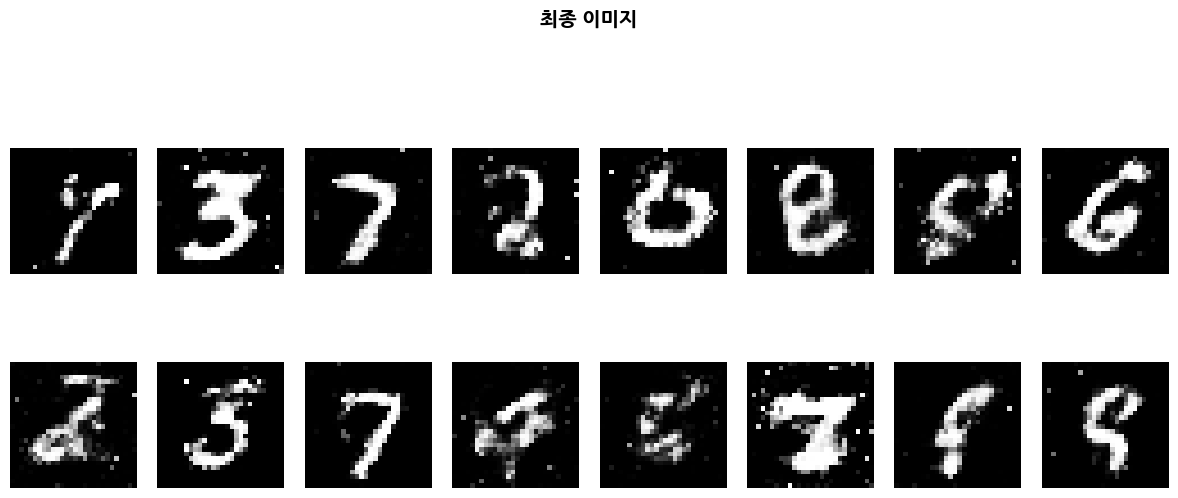

In [18]:
generator.eval()

with torch.no_grad():
    # random noise 이미지 생성
    random_noise = torch.randn(16, latent_dim).to(device)
    generated_images = generator(random_noise)
    generated_images = generated_images.view(-1, 1, 28, 28).cpu()
    generated_images = generated_images * 0.5 + 0.5

# 시각화
plt.figure(figsize=(12, 6))
for i in range(16):
    plt.subplot(2, 8, i+1)
    plt.imshow(generated_images[i][0], cmap='gray')
    plt.axis('off')
plt.suptitle(f'최종 이미지', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

학습 전 vs 학습 후 비교

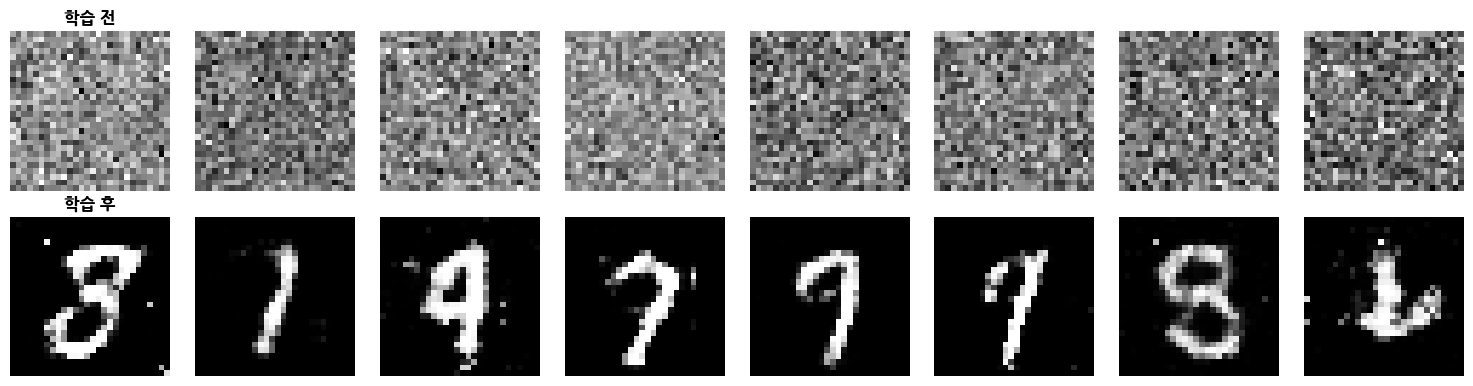

In [19]:
generator.eval()


with torch.no_grad():
    # 학습 후 이미지 (고정된 노이즈 사용)
    fake_images_after = generator(fixed_noise)
    fake_images_after = fake_images_after.view(-1, 1, 28, 28).cpu()
    fake_images_after = fake_images_after * 0.5 + 0.5


# 비교 시각화
fig, axes = plt.subplots(2, 8, figsize=(15, 4))


for i in range(8):
    # 학습 전
    axes[0, i].imshow(fake_images_before[i][0], cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('학습 전', fontweight='bold', fontsize=12)


    # 학습 후
    axes[1, i].imshow(fake_images_after[i][0], cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('학습 후', fontweight='bold', fontsize=12)


plt.tight_layout()
plt.show()

Discrminator 성능 테스

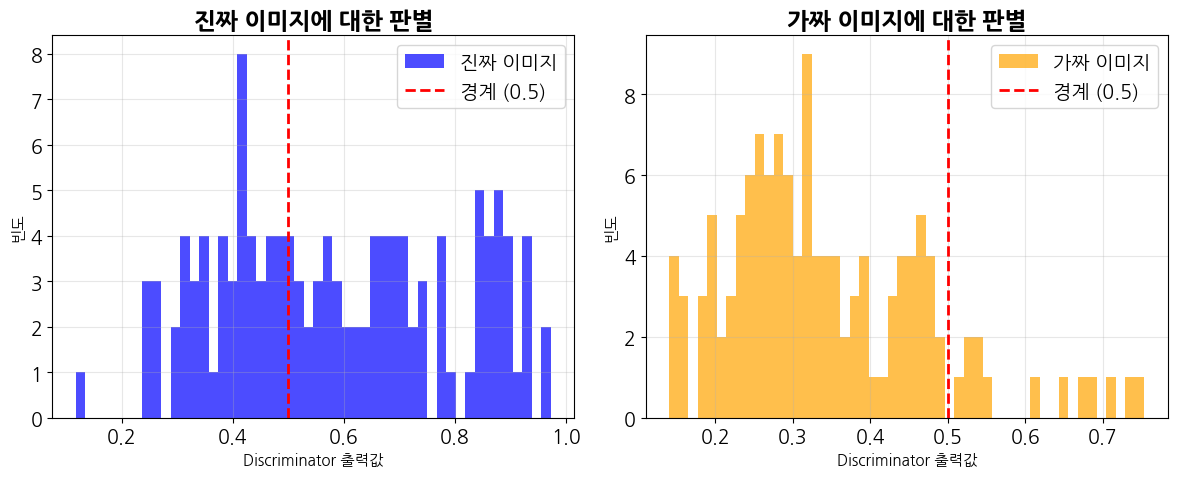

진짜 이미지 평균 점수: 0.5841
가짜 이미지 평균 점수: 0.3442

 이상적인 경우:
- 진짜 이미지는 1에 가까움 (Discriminator가 진짜로 인식)
- 가짜 이미지는 0.5 근처 (Generator가 Discriminator를 잘 속임)


In [20]:
discriminator.eval()
generator.eval()


with torch.no_grad():
    # 진짜 이미지 가져오기
    real_test_images, _ = next(iter(train_loader))
    real_test_images = real_test_images.view(real_test_images.size(0), -1).to(device)


    # 가짜 이미지 생성
    test_noise = torch.randn(batch_size, latent_dim).to(device)
    fake_test_images = generator(test_noise)


    # Discriminator 판별
    real_scores = discriminator(real_test_images).cpu().numpy()
    fake_scores = discriminator(fake_test_images).cpu().numpy()


# 결과 시각화
plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.hist(real_scores, bins=50, alpha=0.7, color='blue', label='진짜 이미지')
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='경계 (0.5)')
plt.xlabel('Discriminator 출력값', fontsize=11)
plt.ylabel('빈도', fontsize=11)
plt.title('진짜 이미지에 대한 판별', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)


plt.subplot(1, 2, 2)
plt.hist(fake_scores, bins=50, alpha=0.7, color='orange', label='가짜 이미지')
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='경계 (0.5)')
plt.xlabel('Discriminator 출력값', fontsize=11)
plt.ylabel('빈도', fontsize=11)
plt.title('가짜 이미지에 대한 판별', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()


print(f"진짜 이미지 평균 점수: {real_scores.mean():.4f}")
print(f"가짜 이미지 평균 점수: {fake_scores.mean():.4f}")
print("\n 이상적인 경우:")
print("- 진짜 이미지는 1에 가까움 (Discriminator가 진짜로 인식)")
print("- 가짜 이미지는 0.5 근처 (Generator가 Discriminator를 잘 속임)")